In [7]:
# basic notebook for plotting logos from annotated seqlets for highlighting specific examples #

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import torch
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
import logomaker

In [2]:
# load all plotLogo tensors
all_plotLogos = torch.load(f'../processed_data/seqlets/dELS_10K_sample_plotLogo_tensors.pt')
# subset for only the relevant enhancer
enhancerIDs = ['EH38E3356274_REF_REF', 'EH38E3356274_chr2_86221285_A_G_b38']
cellTypes = ['K562', 'HepG2', 'SKNSH']
EH38E3356274_subset = subset = {
    ct: {eid: all_plotLogos[ct][eid] for eid in enhancerIDs if eid in all_plotLogos[ct]}
    for ct in cellTypes if ct in all_plotLogos
}
torch.save(EH38E3356274_subset, "../processed_data/EH38E3356274_plotLogo_tensors.pt")

In [10]:
def plot_specific_enhancers(enhancer_id,
                            enhStart,
                            chrom,
                            collapsedSeqletBED,
                            LeadVar,
                            otherVars,
                            cell,
                            output):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    
    # load the tensors
    plotLogo_tensors = torch.load(f'../processed_data/seqlets/dELS_10K_sample_plotLogo_tensors.pt')
    
    # get the seqlets for the BED file
    enhBED = collapsedSeqletBED[collapsedSeqletBED['enhancer_id'] == enhancer_id]
    
    # pull the tensors for the enhancer for that cell type
    tensors2plot = plotLogo_tensors[cell][enhancer_id]
    
    # get the max/min attributions for highlighting seqlets
    minAttrib = tensors2plot.min().min() * 1.05
    maxAttrib = tensors2plot.max().max() * 1.05
    
    # build the DF for plotting with logomaker
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy()
    renamedDF = dfFromTensor.rename(columns={0: 'A', 1: 'C', 2: 'G', 3: 'T'})
    
    # remove zero-padded positions at ends
    renamedDF = renamedDF.loc[renamedDF.sum(axis=1) != 0]
    
    # adjust enhStart to account for left padding, then reset index to start at 0
    enhStart = enhStart + renamedDF.index[0]
    renamedDF = renamedDF.reset_index(drop=True)
    seq_length = len(renamedDF)
    
    # set plot parameters
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300
    
    # generate base plot with extra space for annotations
    fig, ax = plt.subplots(figsize=[20, 2.5])
    logoCheck = logomaker.Logo(renamedDF, ax=ax)
    
    # set y-limits based on data only
    logoCheck.ax.set_ylim(minAttrib, maxAttrib)
    
    # track annotation positions to avoid collisions
    top_annotations = []
    bottom_annotations = []
    min_spacing = 3
    
    def get_annotation_level(x_center, text_half_width, existing_annotations):
        """Find the lowest level where this annotation won't overlap with others."""
        level = 0
        while True:
            conflict = False
            for other_center, other_half_width, other_level in existing_annotations:
                if other_level == level:
                    distance = abs(x_center - other_center)
                    min_dist = text_half_width + other_half_width + min_spacing
                    if distance < min_dist:
                        conflict = True
                        break
            if not conflict:
                return level
            level += 1
    
    # highlight seqlets and collect annotation info
    for idx, row in enhBED.iterrows():
        start, stop, actClass, tf = row[['start', 'end', 'activity_class', 'tf_family']].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        x_center = (stop + start) / 2
        x_center_norm = x_center / seq_length  # normalize to 0-1 for axes coords
        tf_label = tf.split('_')[0]
        text_half_width = len(tf_label) * 2.5
        
        if actClass == 'Activator':
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', floor=0)
            
            level = get_annotation_level(x_center, text_half_width, top_annotations)
            top_annotations.append((x_center, text_half_width, level))
            
            # annotate in axes coords (outside plot area)
            y_offset = 1.05 + level * 0.05
            ax.annotate(tf_label,
                        xy=(x_center_norm, 1.0),  # anchor at top of axes
                        xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset),
                        textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='bottom',
                        annotation_clip=False)
        else:
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', ceiling=0)
            
            level = get_annotation_level(x_center, text_half_width, bottom_annotations)
            bottom_annotations.append((x_center, text_half_width, level))
            
            # annotate in axes coords (outside plot area)
            y_offset = -0.01 - level * 0.12
            ax.annotate(tf_label,
                        xy=(x_center_norm, 0.0),  # anchor at bottom of axes
                        xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset),
                        textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='top',
                        annotation_clip=False)
    
    # highlight lead Variant
    LeadVar = int(LeadVar - enhStart - 1)
    lead_contribution = renamedDF.iloc[LeadVar].sum()
    if lead_contribution >= 0:
        logoCheck.highlight_position(p=LeadVar, color='red', alpha=0.5, floor=0)
    else:
        logoCheck.highlight_position(p=LeadVar, color='red', alpha=0.5, ceiling=0)

    # highlight larger effect variants
    for var in otherVars:
        var2plot = int(var - enhStart - 1)
        var_contribution = renamedDF.iloc[var2plot].sum()
        if var_contribution >= 0:
            logoCheck.highlight_position(p=var2plot, color='deepskyblue', alpha=0.25, floor=0)
        else:
            logoCheck.highlight_position(p=var2plot, color='deepskyblue', alpha=0.25, ceiling=0)
    
    logoCheck.style_spines(visible=False)
    
    # set x-axis ticks to genomic positions at 50bp intervals
    first_tick_genomic = ((enhStart // 50) + 1) * 50
    tick_positions = []
    tick_labels = []
    
    for genomic_pos in range(first_tick_genomic, enhStart + seq_length, 50):
        plot_pos = genomic_pos - enhStart
        if 0 <= plot_pos < seq_length:
            tick_positions.append(plot_pos)
            tick_labels.append(str(genomic_pos))
    
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)

    first_minor_genomic = ((enhStart // 10) + 1) * 10
    first_major_genomic = ((enhStart // 50) + 1) * 50

    major_tick_positions = []
    major_tick_labels = []
    minor_tick_positions = []

    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:  # major tick
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:  # minor tick
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)

    ax.set_xticks(minor_tick_positions, minor=True)
    ax.tick_params(axis='x', which='minor', length=2.5)
    
    plt.title(f'{enhancer_id} | {cell}', loc='left')
    
    # adjust subplot to make room for annotations
    plt.subplots_adjust(top=0.75, bottom=0.25)

In [4]:
# define function for reformatting collapsed mpac seqlet calls:
def mpac_collapsed_dels (path2bed,
                    motif_dict):
    # open bed file
    bed = pd.read_csv(path2bed, sep = '\t', header = None)
    filtered_bed = bed.copy()
    filtered_bed[4] = [i.split('_')[0] for i in filtered_bed[3]]
    filtered_bed[6] = ['activator' if float(i.split('_')[-1]) > 0 else 'repressor' for i in filtered_bed[3]]
    filtered_bed[7] = [i.split('_')[2] for i in filtered_bed[3]]
    # Use column 4 (rep_tf) which has the TF with highest |contribution| for multi-TF intervals
    # Try multiple HOCOMOCO suffixes since they vary (.A, .B, .C, .D)
    def get_tf_family(rep_tf, motif_dict):
        for suffix in ['.A', '.B', '.C', '.D']:
            key = f"{rep_tf}_HUMAN.H11MO.0{suffix}"
            if key in motif_dict:
                return motif_dict[key]
        return None
    # reformat the bed for plotting purposes
    bed2plot = pd.DataFrame({'chrom' : filtered_bed[0],
                             'start' : filtered_bed[1],
                             'end' : filtered_bed[2],
                             'tf' : filtered_bed[4],  # Use pre-computed rep_tf from column 5
                             'tf_family' : [get_tf_family(tf, motif_dict) for tf in filtered_bed[4]],
                             'activity_class' : filtered_bed[6],
                             'enhancer_id' : [f'{i}_REF_REF' if i == 'EH38E3356274' else i for i in filtered_bed[7]]})
    return bed2plot

In [5]:
# open vierstra clusters for collapsing on families instead of tfs
vierstra_motifs = pd.read_excel('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/gnomad_buffering_analysis/motif_annotations.xlsx', sheet_name=[0,1])
# make a dictionary out of the clusterIDs and Names - this will be used to generate the final dictionary with the motif names
idName_dict = dict(zip(vierstra_motifs[0]['Cluster_ID'], vierstra_motifs[0]['Name']))
# open the second page and assign the Names to the individual motifs
vierstra_motifs[1].loc[:,'cluster_name'] = [idName_dict.get(i) for i in vierstra_motifs[1]['Cluster_ID']]
# make a dictionary that pulls the motif name as a key and returns the vierstra family as a value
vierstra_motif_dict = dict(zip(vierstra_motifs[1]['Motif'], vierstra_motifs[1]['cluster_name']))

In [6]:
# reformat MPAC collapsed BED files
path2beds = '../processed_data/seqlets/bed_files'
# k562
k_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/dELS_100K_sample_K562_0.01.bed',
                                            vierstra_motif_dict)
# hepg2
h_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/dELS_100K_sample_HepG2_0.01.bed',
                                            vierstra_motif_dict)
# sknsh
s_mpac_collapsed_dels = mpac_collapsed_dels(f'{path2beds}/dELS_100K_sample_SKNSH_0.01.bed',
                                            vierstra_motif_dict)

In [7]:
k_mpac_collapsed_dels[k_mpac_collapsed_dels['enhancer_id'] == 'EH38E3356274_REF_REF']

,chrom,start,end,tf,tf_family,activity_class,enhancer_id
6207,chr2,86221325,86221331,FOXI1,NFY,activator,EH38E3356274_REF_REF


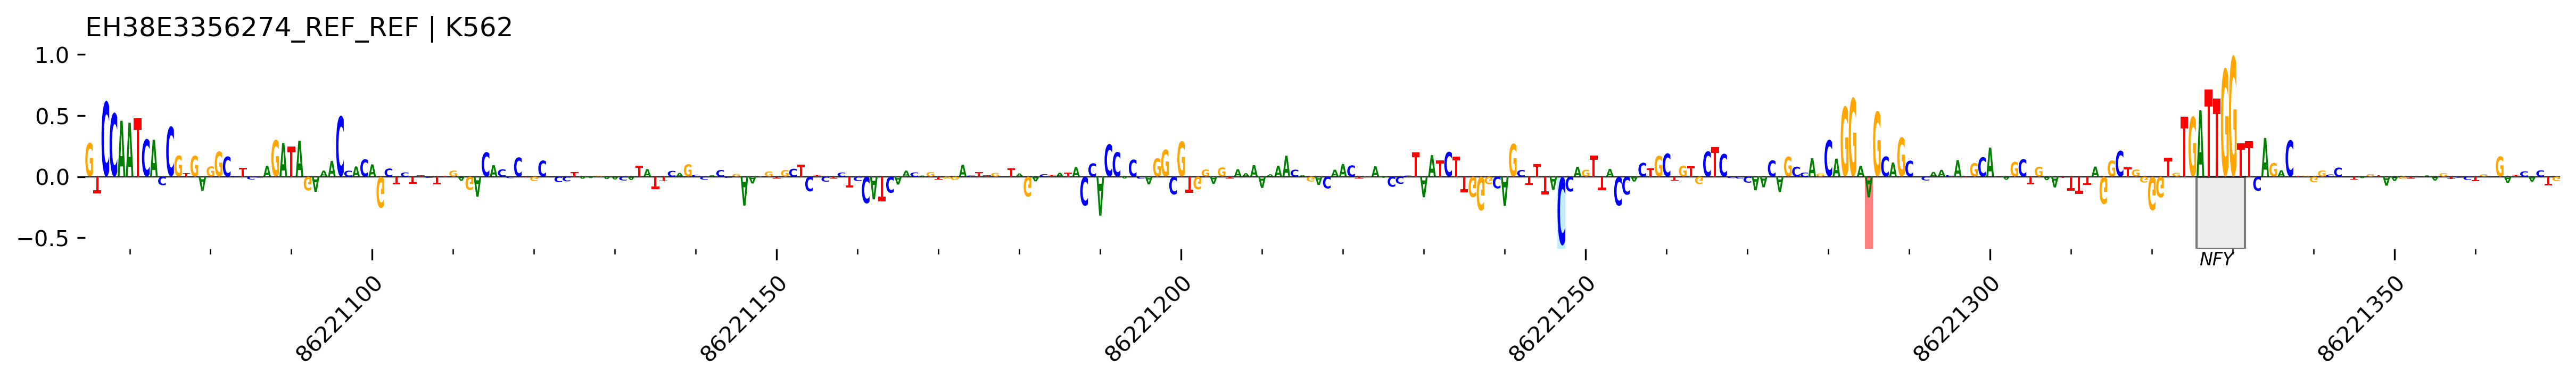

In [11]:
plot_specific_enhancers(
    'EH38E3356274_REF_REF',
    86221064,
    'chr2',
    k_mpac_collapsed_dels,
    86221285,
    [86221247],
    'K562',
    ''
)

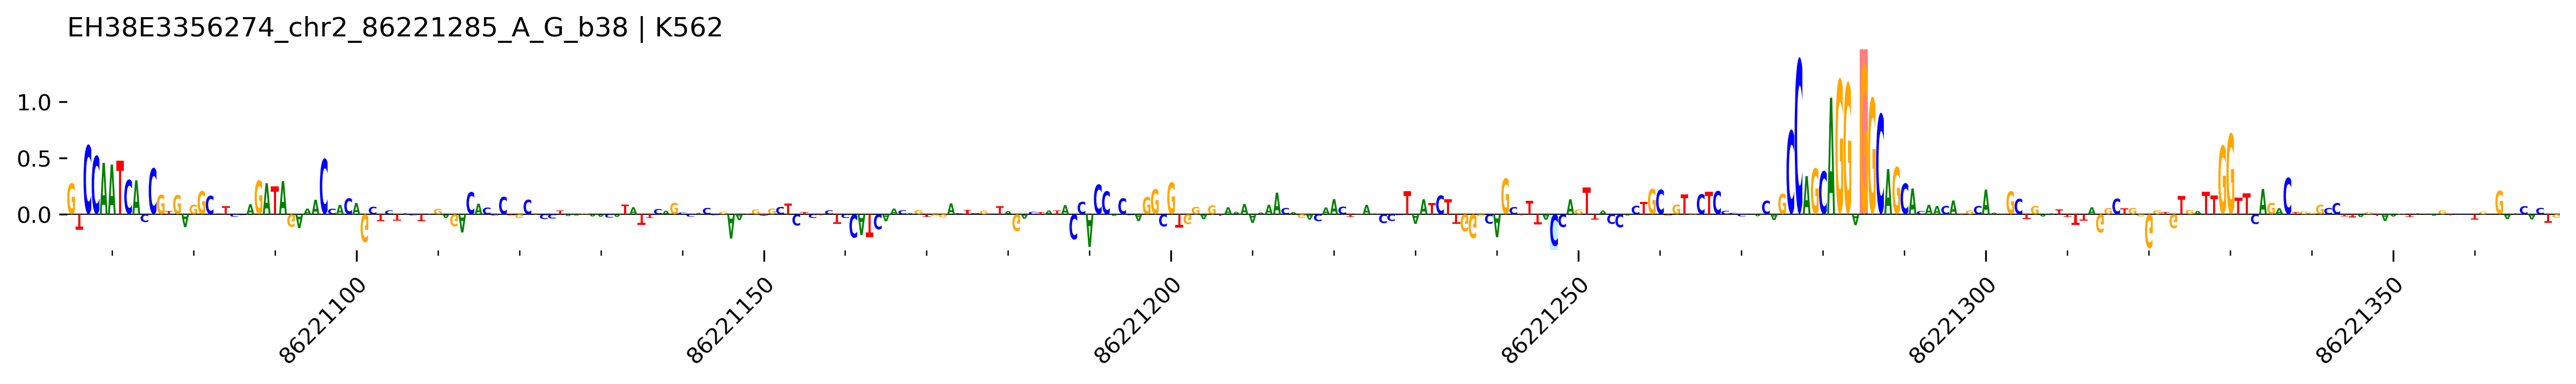

In [12]:
plot_specific_enhancers(
    'EH38E3356274_chr2_86221285_A_G_b38',
    86221064,
    'chr2',
    k_mpac_collapsed_dels,
    86221285,
    [86221247],
    'K562',
    ''
)